# 01 — CNN Training — ResNet-50 (ISIC 2019)

Training **ResNet-50** (CNN baseline) on ISIC 2019 for skin lesion classification (8 classes).

**Reference:** *Zammit & Murugan — "Enhanced Multi-Class Skin Lesion Classification of Dermoscopic Images Using an Ensemble of Deep Learning Models"* (JCTA 2025)

**Paper parameters applied:**
| Parameter | Value |
|-----------|-------|
| Image size | 224×224 |
| Split | 80% train / 20% val + official test (stratified) |
| Epochs | 150 |
| Optimizer | Adam (lr=1e-4, wd=**1e-5**) |
| Loss | **Focal Loss** (α=Table 6, γ=2) |
| Class balancing | WeightedRandomSampler |
| Augmentation | Resize 256→RandomCrop 224, Flip×2, Rotate90, Grid/Optical distortion, Affine, ColorJitter (p=0.3–0.5) |
| Dropout | drop_rate=0.3 |
| Unfreezing | Warmup 10 epochs (head only) → full fine-tune |

**Role in thesis:** ResNet-50 = unique CNN baseline (contrôle positif) pour comparer avec les 4 ViTs.

**Environment:** Kaggle (GPU T4 / P100)

## 0. Kaggle Setup — Clone repo & install deps

In [1]:
# Run once — remove old version if exists
!rm -rf /kaggle/working/xai-vit-medical
!git clone https://github.com/youssef-nouiouar/xai-vit-medical.git /kaggle/working/xai-vit-medical

Cloning into '/kaggle/working/xai-vit-medical'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 95 (delta 20), reused 85 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 407.92 KiB | 4.97 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [2]:
!pip install -q timm albumentations loguru
!pip install -q PyDrive2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 1.7 MB/s eta 0:00:00


In [3]:
# Google Drive authentication (to save checkpoints)
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

## 0b. Download ISIC 2019 Dataset

In [4]:
import os, requests, zipfile

DATA_DIR = '/kaggle/working/xai-vit-medical/data/isic2019'
os.makedirs(DATA_DIR, exist_ok=True)

URLS = {
    'train_zip': 'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip',
    'train_csv': 'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv',
    'test_zip':  'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip',
    'test_csv':  'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv',
}

def download(url, dest):
    print(f'Downloading {os.path.basename(dest)} ...')
    r = requests.get(url, stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f'  done ({os.path.getsize(dest)/1e6:.1f} MB)')

def extract_and_remove(zip_path, extract_to):
    print(f'Extracting {os.path.basename(zip_path)} ...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    os.remove(zip_path)
    print('  done.')

# Training set
train_zip = f'{DATA_DIR}/ISIC_2019_Training_Input.zip'
download(URLS['train_zip'], train_zip)
extract_and_remove(train_zip, DATA_DIR)
download(URLS['train_csv'], f'{DATA_DIR}/ISIC_2019_Training_GroundTruth.csv')

# Test set
test_zip = f'{DATA_DIR}/ISIC_2019_Test_Input.zip'
download(URLS['test_zip'], test_zip)
extract_and_remove(test_zip, DATA_DIR)
download(URLS['test_csv'], f'{DATA_DIR}/ISIC_2019_Test_GroundTruth.csv')

print('\nDataset ready.')

  done.
  done (1.3 MB)
  done (3823.2 MB)
Extracting ISIC_2019_Test_Input.zip ...
  done.
  done (0.5 MB)

Dataset ready.


## 1. Setup & Dependencies

In [ ]:
import os, sys, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix

# Project root
PROJECT_ROOT = '/kaggle/working/xai-vit-medical'
sys.path.insert(0, PROJECT_ROOT)

from src.data.isic_dataset import ISICDataset
from src.utils.seed import set_seed

# Reproducibility
SEED = 42
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU   : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('Dependencies loaded.')

## 2. Configuration

Paramètres du papier (Zammit & Murugan 2025) :

In [ ]:
# ---- Paths ----
DATA_DIR  = '/kaggle/working/xai-vit-medical/data/isic2019'
SAVE_DIR  = '/kaggle/working/xai-vit-medical/outputs/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- Dataset ----
IMAGE_SIZE  = 224
NUM_CLASSES = 8
VAL_RATIO   = 0.20      # paper: 80/20 split
NUM_WORKERS = 2

# ---- Training ----
BATCH_SIZE   = 32
EPOCHS       = 150
LR           = 1e-4
WEIGHT_DECAY = 1e-5     # paper: Section 3.7 (was 1e-4)
PATIENCE     = 15

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
CLASS_NAMES_FULL = {
    'MEL':'Melanoma', 'NV':'Naevus mélanocytaire',
    'BCC':'Carcinome basocellulaire', 'AK':'Kératose actinique',
    'BKL':'Kératose bénigne', 'DF':'Dermatofibrome',
    'VASC':'Lésion vasculaire', 'SCC':'Carcinome épidermoïde'
}

# ---- Focal Loss alpha — class weights from Table 6 (Zammit & Murugan 2025) ----
# Order: MEL, NV, BCC, AK, BKL, DF, VASC, SCC
FOCAL_ALPHA = torch.tensor([0.3, 0.1, 0.4, 0.7, 0.5, 1.0, 1.0, 0.7], dtype=torch.float)

print('Configuration:')
for k, v in [('Image size', f'{IMAGE_SIZE}×{IMAGE_SIZE}'), ('Batch size', BATCH_SIZE),
             ('Epochs', EPOCHS), ('LR', LR), ('Weight decay', WEIGHT_DECAY),
             ('Val ratio', VAL_RATIO), ('Num classes', NUM_CLASSES)]:
    print(f'  {k:14s}: {v}')
print(f'  {"Focal alpha":14s}: {FOCAL_ALPHA.tolist()}')

## 3. Dataset & DataLoaders

**Augmentations corrigées (fixes overfitting) :**

| Augmentation | Probabilité | Note |
|---|---|---|
| Resize 256 → RandomCrop 224 | 1.0 | Remplace le CenterCrop no-op |
| Horizontal Flip | 0.5 | ↑ depuis 0.1 |
| Vertical Flip | 0.5 | ↑ depuis 0.1 |
| Random Rotate 90° | 0.5 | ↑ depuis 0.1 |
| Grid Distortion | 0.3 | ↑ depuis 0.1 |
| Optical Distortion | 0.3 | ↑ depuis 0.1 |
| Affine Transformation | 0.3 | ↑ depuis 0.1 |
| Color Jitter | 0.4 | Nouveau |

**Val/Test transform :** Resize 256 → CenterCrop 224 → Normalize

**Équilibrage des classes :** WeightedRandomSampler (Section 3.3 du papier)

In [9]:
def get_train_transform(image_size: int = 224) -> A.Compose:
    """Augmentations corrigées : resize 256 → RandomCrop 224, p=0.3-0.5."""
    return A.Compose([
        A.Resize(256, 256),                  # canvas plus large pour que le crop ait un effet réel
        A.RandomCrop(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.GridDistortion(distort_limit=0.3, p=0.3),
        A.OpticalDistortion(distort_limit=0.05, p=0.3),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.1, 0.1),
                 rotate=(-30, 30), shear=(-10, 10), p=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transform(image_size: int = 224) -> A.Compose:
    """Val/Test : resize 256, center crop 224, normalize."""
    return A.Compose([
        A.Resize(256, 256),
        A.CenterCrop(image_size, image_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

# ---- Datasets ----
# use_official_test=True  → train/val from ISIC_2019_Training_Input
#                           test  from ISIC_2019_Test_Input
train_dataset = ISICDataset(
    root_dir=DATA_DIR, split='train',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
train_dataset.use_albumentations = True
train_dataset.transform = get_train_transform(IMAGE_SIZE)

val_dataset = ISICDataset(
    root_dir=DATA_DIR, split='val',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
val_dataset.use_albumentations = True
val_dataset.transform = get_val_transform(IMAGE_SIZE)

test_dataset = ISICDataset(
    root_dir=DATA_DIR, split='test',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
test_dataset.use_albumentations = True
test_dataset.transform = get_val_transform(IMAGE_SIZE)

# ---- Distribution + WeightedRandomSampler ----
class_counts = Counter(train_dataset.labels)
total = len(train_dataset)
print(f'Train : {total} images')
print(f'Val   : {len(val_dataset)} images')
print(f'Test  : {len(test_dataset)} images')
print('\nDistribution (train):')
for i, name in enumerate(CLASS_NAMES):
    cnt = class_counts.get(i, 0)
    print(f'  {name:5s}: {cnt:>5d}  ({cnt/total*100:.1f}%)')

class_weights = torch.tensor(
    [total / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
)
sample_weights = class_weights[train_dataset.labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True)

# ---- DataLoaders ----
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Class weights : {class_weights.numpy().round(2)}')

Train : 18998 images
Val   : 6333 images
Test  : 8238 images

Distribution (train):
  MEL  :  3392  (17.9%)
  NV   :  9656  (50.8%)
  BCC  :  2492  (13.1%)
  AK   :   650  (3.4%)
  BKL  :  1968  (10.4%)
  DF   :   179  (0.9%)
  VASC :   190  (1.0%)
  SCC  :   471  (2.5%)

Train batches : 593
Val   batches : 99
Test  batches : 129
Class weights : [ 0.7   0.25  0.95  3.65  1.21 13.27 12.5   5.04]


In [ ]:
# ---- Diagnostic : class distribution across all splits ----
# Expliquer le gap val/test : le test officiel ISIC 2019 a une distribution différente du train
print(f'{"Split":6s}  {"Total":>6s}  ' + '  '.join(f'{n:>5s}' for n in CLASS_NAMES))
print('-' * 70)

for name, ds in [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]:
    counts = Counter(ds.labels)
    total  = len(ds)
    row    = '  '.join(f'{counts.get(i, 0)/total*100:5.1f}%' for i in range(NUM_CLASSES))
    print(f'{name:6s}  {total:>6d}  {row}')

print()
# Sanity check : no image overlap between train and val
train_ids = set(train_dataset.data['image'].tolist())
val_ids   = set(val_dataset.data['image'].tolist())
overlap   = train_ids & val_ids
print(f'Train/Val overlap : {len(overlap)} images  (should be 0)')
print()
print('NOTE : if the Test distribution differs significantly from Train/Val,')
print('       the val/test accuracy gap is a dataset shift issue, not a code bug.')

## 4. Model — ResNet-50

- Pré-entraîné ImageNet (transfer learning)
- **`drop_rate=0.3`** — dropout avant la tête de classification (régularisation)
- Tête de classification : FC → 8 classes

In [10]:
def build_resnet50(num_classes: int = NUM_CLASSES, pretrained: bool = True) -> nn.Module:
    """ResNet-50 depuis timm, drop_rate=0.3 pour régularisation."""
    model = timm.create_model(
        'resnet50', pretrained=pretrained, num_classes=num_classes, drop_rate=0.3
    )
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'ResNet-50  (pretrained={pretrained}, drop_rate=0.3)')
    print(f'  Classifier : {model.get_classifier()}')
    print(f'  Params total     : {total:,}')
    print(f'  Params trainable : {trainable:,}')
    return model

# Architecture check
_m = build_resnet50()
_x = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
assert _m(_x).shape == (1, NUM_CLASSES), 'Shape mismatch'
del _m, _x
torch.cuda.empty_cache()
print('Architecture OK.')

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet-50  (pretrained=True, drop_rate=0.3)
  Classifier : Linear(in_features=2048, out_features=8, bias=True)
  Params total     : 23,524,424
  Params trainable : 23,524,424
Architecture OK.


## 5. Training Loop

| Composant | Choix | Note |
|-----------|-------|------|
| Loss | **FocalLoss** (α=Table 6, γ=2) | Remplace CrossEntropy — gère le déséquilibre |
| Optimizer | Adam (lr=1e-4, **wd=1e-5**) | Section 3.7 du papier |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) | Stabilité |
| Mixed Precision | torch.amp (FP16) | Vitesse + mémoire |
| Early stopping | patience=15 sur val_loss | Anti-overfitting |
| Epochs | 150 | Section 4 |
| **Warmup (10 ep.)** | **Tête seulement → backbone dégelé à epoch 11** | Progressive unfreezing |

In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al. 2017) avec pondération par classe.

    alpha : tensor de poids par classe (Table 6 — Zammit & Murugan 2025)
    gamma : facteur de focus (2.0 par défaut)
    """
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.register_buffer('alpha', alpha)
        self.gamma = gamma

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss  = F.cross_entropy(inputs, targets, reduction='none')
        pt       = torch.exp(-ce_loss)
        alpha_t  = self.alpha[targets]
        return (alpha_t * (1.0 - pt) ** self.gamma * ce_loss).mean()


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scaler: torch.cuda.amp.GradScaler,
    device: torch.device,
) -> tuple[float, float]:
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, labels, _ in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels, _ in tqdm(loader, desc='  Eval ', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = EPOCHS,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    patience: int = PATIENCE,
    warmup_epochs: int = 10,
    device: torch.device = DEVICE,
) -> tuple[nn.Module, dict]:
    model = model.to(device)

    # Phase 1 — backbone gelé, seule la tête est entraînée
    for name, param in model.named_parameters():
        if 'fc' not in name:
            param.requires_grad = False
    n_head = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Warmup ({warmup_epochs} epochs) : tête seulement ({n_head:,} params)')

    criterion = FocalLoss(alpha=FOCAL_ALPHA.to(device), gamma=2.0)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    save_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')

    print(f'\n{"="*60}')
    print(f'Training {model_name}  |  {epochs} epochs  |  lr={lr}  |  patience={patience}')
    print(f'{"="*60}\n')

    for epoch in range(1, epochs + 1):

        # Phase 2 — dégel complet du backbone après warmup
        if epoch == warmup_epochs + 1:
            for param in model.parameters():
                param.requires_grad = True
            n_total = sum(p.numel() for p in model.parameters())
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5
            )
            print(f'\n  [Epoch {epoch}] Backbone dégelé — {n_total:,} params entraînables\n')

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch}/{epochs}  (lr={current_lr:.2e})')

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'history': history,
                'class_names': CLASS_NAMES,
                'model_name': model_name,
            }, save_path)
            tag = ' ★'
        else:
            epochs_no_improve += 1

        print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}')
        print(f'  val_loss  ={val_loss:.4f}  val_acc  ={val_acc:.4f}{tag}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

    print(f'\nBest val_loss={best_val_loss:.4f} — checkpoint: {save_path}')
    return model, history

print('FocalLoss + training functions defined.')

## 6. Train ResNet-50

In [12]:
resnet50 = build_resnet50(num_classes=NUM_CLASSES, pretrained=True)

resnet50, resnet50_history = train_model(
    model=resnet50,
    model_name='resnet50',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    warmup_epochs=10,
    device=DEVICE,
)

ResNet-50  (pretrained=True, drop_rate=0.3)
  Classifier : Linear(in_features=2048, out_features=8, bias=True)
  Params total     : 23,524,424
  Params trainable : 23,524,424
  Warmup (10 epochs) : tête seulement (16,392 params)

Training resnet50  |  150 epochs  |  lr=0.0001  |  patience=15

Epoch 1/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Eval :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=2.0240  train_acc=0.2682
  val_loss  =1.9446  val_acc  =0.4180 ★
Epoch 2/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.4902  train_acc=0.9923
  val_loss  =0.8198  val_acc  =0.8645
Epoch 82/150  (lr=3.13e-06)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Eval :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.4912  train_acc=0.9908
  val_loss  =0.8186  val_acc  =0.8670

Early stopping at epoch 82 (no improvement for 15 epochs)

Best val_loss=0.8183 — checkpoint: /kaggle/working/xai-vit-medical/outputs/models/resnet50_best.pth


## 7. Evaluation & Results

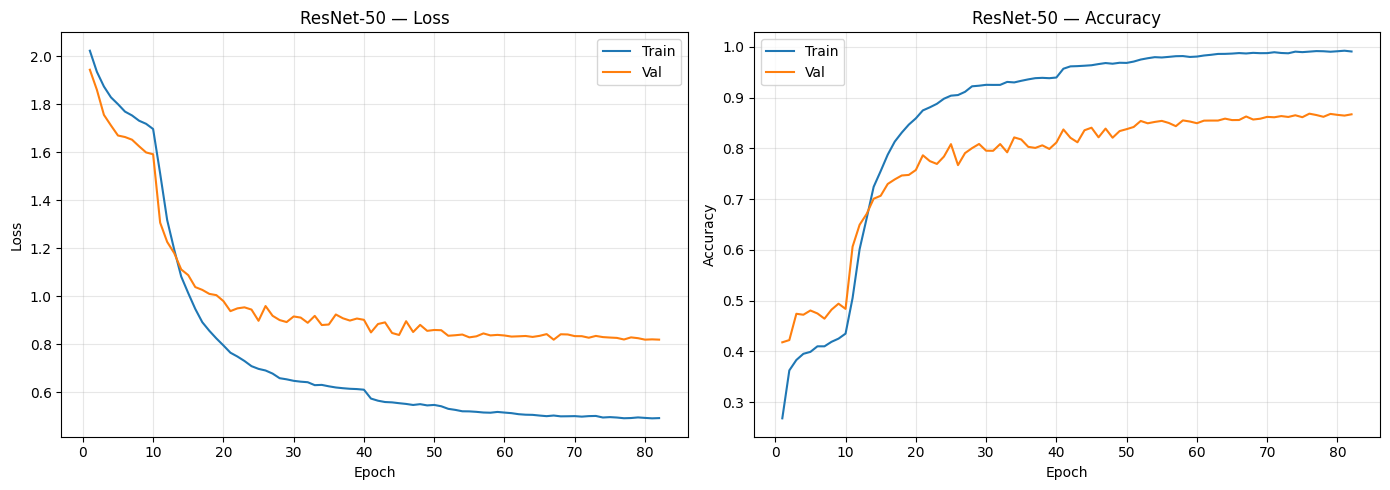

Saved: /kaggle/working/xai-vit-medical/outputs/models/ResNet-50_curves.png


In [13]:
def plot_training_curves(history: dict, model_name: str) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs_range, history['train_loss'], label='Train')
    ax1.plot(epochs_range, history['val_loss'],   label='Val')
    ax1.set(xlabel='Epoch', ylabel='Loss', title=f'{model_name} — Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, history['train_acc'], label='Train')
    ax2.plot(epochs_range, history['val_acc'],   label='Val')
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title=f'{model_name} — Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_curves.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')


def evaluate_full(
    model: nn.Module,
    loader: DataLoader,
    model_name: str,
    split: str = 'val',
    device: torch.device = DEVICE,
) -> dict:
    loss, acc, preds, labels = evaluate(model, loader, nn.CrossEntropyLoss(), device)
    print(f'\n{model_name} — {split.upper()} SET')
    print(f'  Loss     : {loss:.4f}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'\n{classification_report(labels, preds, target_names=CLASS_NAMES, digits=4)}')

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set(xlabel='Predicted', ylabel='True',
           title=f'{model_name} — Confusion Matrix ({split})')
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_cm_{split}.png')
    plt.savefig(out, dpi=150)
    plt.show()
    return {'loss': loss, 'acc': acc, 'preds': preds, 'labels': labels}


# ---- Courbes d'entraînement ----
plot_training_curves(resnet50_history, 'ResNet-50')

Best checkpoint: epoch 67  val_loss=0.8183  val_acc=0.8628


  Eval :   0%|          | 0/99 [00:00<?, ?it/s]


ResNet-50 — VAL SET
  Loss     : 0.4980
  Accuracy : 0.8628  (86.28%)

              precision    recall  f1-score   support

         MEL     0.7638    0.8097    0.7861      1130
          NV     0.9103    0.9108    0.9106      3219
         BCC     0.8953    0.8953    0.8953       831
          AK     0.7989    0.6959    0.7438       217
         BKL     0.7910    0.7790    0.7849       656
          DF     0.7759    0.7500    0.7627        60
        VASC     0.9655    0.8889    0.9256        63
         SCC     0.8333    0.7006    0.7612       157

    accuracy                         0.8628      6333
   macro avg     0.8418    0.8038    0.8213      6333
weighted avg     0.8634    0.8628    0.8627      6333



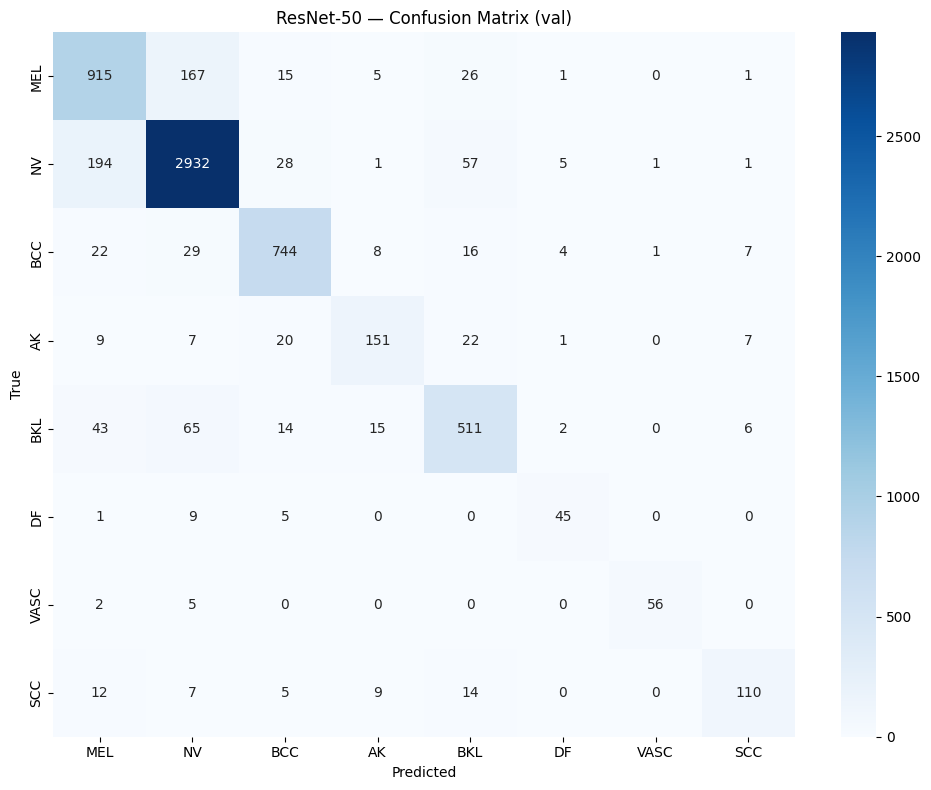

In [14]:
# ---- Évaluation sur val set ----
# Charger le meilleur checkpoint
ckpt = torch.load(os.path.join(SAVE_DIR, 'resnet50_best.pth'), map_location=DEVICE)
resnet50.load_state_dict(ckpt['model_state_dict'])
print(f"Best checkpoint: epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}  val_acc={ckpt['val_acc']:.4f}")

resnet50_val_results = evaluate_full(resnet50, val_loader, 'ResNet-50', split='val')

  Eval :   0%|          | 0/129 [00:00<?, ?it/s]


ResNet-50 — TEST SET
  Loss     : 1.6040
  Accuracy : 0.5556  (55.56%)

              precision    recall  f1-score   support

         MEL     0.7032    0.3666    0.4820      3374
          NV     0.6874    0.8417    0.7568      2495
         BCC     0.3990    0.7723    0.5262       975
          AK     0.2484    0.2059    0.2251       374
         BKL     0.3488    0.4561    0.3953       660
          DF     0.3469    0.3736    0.3598        91
        VASC     0.3721    0.3077    0.3368       104
         SCC     0.2389    0.2606    0.2493       165

    accuracy                         0.5556      8238
   macro avg     0.4181    0.4481    0.4164      8238
weighted avg     0.5960    0.5556    0.5440      8238



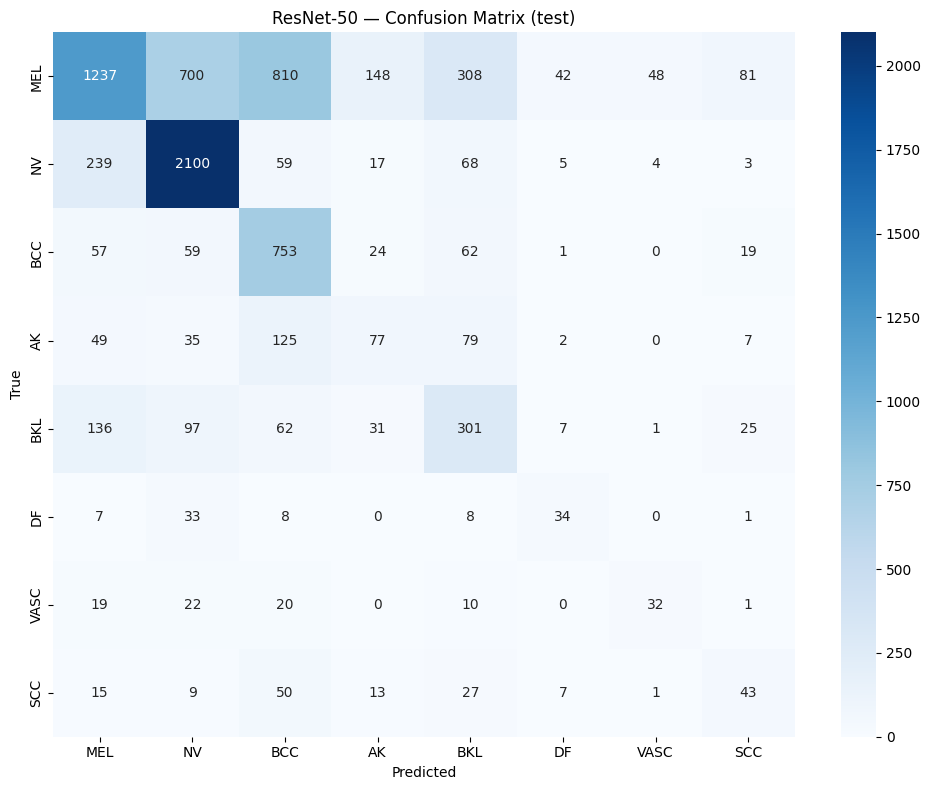

In [15]:
# ---- Évaluation sur test set officiel ----
resnet50_test_results = evaluate_full(resnet50, test_loader, 'ResNet-50', split='test')

## 8. Save Summary & Upload to Google Drive

In [17]:
summary = {
    'resnet50': {
        'val_loss': float(resnet50_val_results['loss']),
        'val_acc':  float(resnet50_val_results['acc']),
        'test_loss': float(resnet50_test_results['loss']),
        'test_acc':  float(resnet50_test_results['acc']),
        'best_epoch': int(ckpt['epoch']),
        'epochs_trained': len(resnet50_history['train_loss']),
    }
}

summary_path = os.path.join(SAVE_DIR, 'cnn_training_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('CNN Training Summary:')
print(f'  val_acc  = {summary["resnet50"]["val_acc"]:.4f}')
print(f'  test_acc = {summary["resnet50"]["test_acc"]:.4f}')
print(f'  best epoch = {summary["resnet50"]["best_epoch"]}')

CNN Training Summary:
  val_acc  = 0.8628
  test_acc = 0.5556
  best epoch = 67


In [18]:
# Upload checkpoint + summary to a specific Drive folder
SAVE_DIR  = '/kaggle/working/xai-vit-medical/outputs/models'
folder_id = "1eq-Jt6O6gO0Ck_oQYwmmc2qrCVLfKlec"   # <--- put your folder ID

files_to_upload = [
    'resnet50_best.pth',
    'cnn_training_summary.json',
    'ResNet-50_curves.png',
    'ResNet-50_cm_val.png',
    'ResNet-50_cm_test.png'
]

for fname in files_to_upload:
    fpath = os.path.join(SAVE_DIR, fname)

    if os.path.exists(fpath):
        drive_file = drive.CreateFile({
            'title': fname,
            'parents': [{'id': folder_id}]
        })

        drive_file.SetContentFile(fpath)
        drive_file.Upload()

        print(f"Uploaded: {fname}  (id={drive_file['id']})")
    else:
        print(f"Not found (skipped): {fname}")

print("\nDone. Files uploaded to folder.")


Uploaded: resnet50_best.pth  (id=1n0LT445CS4FGBIG8oAbtWDpkJw82IuDD)
Uploaded: cnn_training_summary.json  (id=1Y-1PNygLElv5b9vXitl9LPuxx95-WG8M)
Uploaded: ResNet-50_curves.png  (id=1N_6BzMWzdWJJmp6bgOz03bg7LERJ2hmi)
Uploaded: ResNet-50_cm_val.png  (id=15nmmTK275WJl8fOWKF7x18MWKiKzhCgI)
Uploaded: ResNet-50_cm_test.png  (id=1n62yYZ8uVITsam1F_JXohgabJVOY3Tki)

Done. Files uploaded to folder.
